<a href="https://colab.research.google.com/github/SamiraKheradmand/IASC-ASCE-Transformer-SHM/blob/main/notebooks/02_split_methods/chronological/Chronological_acquisition_fingerprint_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chronological Acquisition Fingerprint Diagnostic

## Objective

This notebook investigates whether statistical patterns observed in the
disconnected system-noise channel (DA16) are also present in the connected
structural sensors DA04–DA15.

The analysis uses the same chronological preprocessing protocol as the main
Transformer experiments, but it is a diagnostic analysis rather than a
classification experiment.

Primary statistical features:
- RMS
- STD
- Peak-to-Peak
- Kurtosis

DA16 is used only as a disconnected reference channel.

# 1. Setup and Data Loading

In [4]:
import os
import scipy.io as sio
from scipy.io.matlab._mio5_params import mat_struct
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from pathlib import Path
import re
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [6]:
from pathlib import Path

import numpy as np
import scipy.io as sio


# مسیر فایل‌ها
DATA_DIR = Path("/content/drive/MyDrive/ASCE_IASC/MAT_data")

# فقط 16 سنسور واقعی سازه
CHANNELS = [f"DA{i:02d}" for i in range(1, 17)]

# پیدا کردن فایل‌های 9 حالت سازه
mat_files = sorted(DATA_DIR.glob("shm*.mat"))

print("Folder exists:", DATA_DIR.exists())
print("Number of files:", len(mat_files))
print("Number of channels:", len(CHANNELS))


def load_ambient_file(file_path):
    """
    خواندن یک فایل Ambient از داده‌های IASC-ASCE
    """

    mat = sio.loadmat(file_path,squeeze_me=True,struct_as_record=False)

    dasy = mat["dasy"]
    dasy_dscr = mat["dasy_dscr"]
    fs = float(mat["fsdasy"])

    signals = []
    descriptions = []

    for i, channel in enumerate(CHANNELS, start=1):

        signal = np.asarray(getattr(dasy, channel)).reshape(-1)

        description_name = f"DAdscr{i:02d}"
        description = getattr(dasy_dscr, description_name)

        signals.append(signal)
        descriptions.append(description)

    # شکل خروجی:
    # (تعداد نمونه‌های زمانی، تعداد سنسورها)
    X_raw = np.column_stack(signals)

    return X_raw, fs, descriptions

Folder exists: True
Number of files: 9
Number of channels: 16


## 1.1 DA16 Metadata Check

DA16 is retained as a negative-control reference channel.
Its metadata should identify it as disconnected system noise in all nine cases.

In [7]:
all_cases = {}

for file_path in mat_files:

    case_name = file_path.stem
    case_number = int(case_name[3:5])

    X_raw, fs, descriptions = load_ambient_file(file_path)

    all_cases[case_name] = {
        "X_raw": X_raw,
        "fs": fs,
        "channels": CHANNELS.copy(),
        "descriptions": descriptions,
        "case_number": case_number,
        "label": case_number - 1,
        "file_path": file_path
    }

    print(
        f"{case_name} | "
        f"shape: {X_raw.shape} | "
        f"fs: {fs} Hz | "
        f"label: {case_number - 1}"

    )
print( f"description: {pd.DataFrame(descriptions)}")

shm01a | shape: (60000, 16) | fs: 200.0 Hz | label: 0
shm02a | shape: (60000, 16) | fs: 200.0 Hz | label: 1
shm03a | shape: (60000, 16) | fs: 200.0 Hz | label: 2
shm04a | shape: (60000, 16) | fs: 200.0 Hz | label: 3
shm05a | shape: (60000, 16) | fs: 200.0 Hz | label: 4
shm06a | shape: (45568, 16) | fs: 200.0 Hz | label: 5
shm07a | shape: (180000, 16) | fs: 200.0 Hz | label: 6
shm08a | shape: (180000, 16) | fs: 200.0 Hz | label: 7
shm09a | shape: (180000, 16) | fs: 200.0 Hz | label: 8
description:                                                     0
0        Base West side - EPI sensor X direction (N+)
1           Base Center - EPI sensor Y direction (W+)
2        Base East side - EPI sensor X direction (N+)
3         1st Floor - N/S EPI Sensor at West end (N+)
4           1st Floor - E/W FBA Sensor at Center (W+)
5         1st Floor - N/S FBA Sensor at East end (N+)
6         2nd Floor - N/S FBA Sensor at West end (N+)
7           2nd Floor - E/W EPI Sensor at Center (W+)
8         2n

In [8]:
print(all_cases["shm01a"]["X_raw"].shape)
print(all_cases["shm01a"]["channels"])


(60000, 16)
['DA01', 'DA02', 'DA03', 'DA04', 'DA05', 'DA06', 'DA07', 'DA08', 'DA09', 'DA10', 'DA11', 'DA12', 'DA13', 'DA14', 'DA15', 'DA16']


# 2. Chronological Evaluation Protocol

The same chronological preprocessing used in the main Transformer experiment
is retained to ensure that the statistical diagnostic is evaluated under the
same temporal structure.

## 2.1 Chronological 60/20/20 Split

In [9]:
# ============================================================
# Step 2: Chronological split and Butterworth high-pass filter
# Filter is applied separately to Train, Validation and Test
# ============================================================

import pandas as pd
from scipy.signal import butter, sosfiltfilt


# ----------------------------
# Split settings
# ----------------------------
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20

GAP_SEC = 0
EDGE_SEC = 2


# ----------------------------
# High-pass filter settings
# ----------------------------
CUTOFF = 0.1
ORDER = 2


def highpass_filter(X, fs):

    """
    Apply a Butterworth high-pass filter to all sensor channels.
    X shape:(samples, sensors)
    """

    sos = butter(N=ORDER, Wn=CUTOFF,btype="highpass",fs=fs,output="sos")
    X_filtered = sosfiltfilt(sos,X,axis=0)

    return X_filtered

## 2.2 Independent High-Pass Filtering and Edge Trimming

In [10]:
train_data = {}
val_data = {}
test_data = {}

split_report = []

for case_name in sorted(all_cases.keys()):

    # Raw data
    X = all_cases[case_name]["X_raw"]
    fs = all_cases[case_name]["fs"]

    n_samples = len(X)

    gap_size = int(GAP_SEC * fs)
    edge_size = int(EDGE_SEC * fs)

    # ----------------------------
    # Chronological split boundaries
    # ----------------------------
    train_end = int(TRAIN_RATIO * n_samples)

    val_start = train_end + gap_size
    val_end = val_start + int(VAL_RATIO * n_samples)

    test_start = val_end + gap_size

    if test_start >= n_samples:
        raise ValueError(f"{case_name}: signal is too short for this gap.")

    # ----------------------------
    # Split raw signal
    # ----------------------------
    X_train_raw = X[:train_end]
    X_val_raw = X[val_start:val_end]
    X_test_raw = X[test_start:]

    # Check split lengths
    if min(len(X_train_raw), len(X_val_raw), len(X_test_raw)) <= 2 * edge_size:
        raise ValueError(f"{case_name}: EDGE_SEC is too large.")

    # ----------------------------
    # Filter each split separately
    # ----------------------------
    X_train_filtered = highpass_filter(X_train_raw, fs)
    X_val_filtered  = highpass_filter(X_val_raw, fs)
    X_test_filtered = highpass_filter(X_test_raw, fs)

    # ----------------------------
    # Remove filter edges
    # ----------------------------
    X_train_filtered = X_train_filtered[edge_size:-edge_size]
    X_val_filtered  = X_val_filtered[edge_size:-edge_size]
    X_test_filtered = X_test_filtered[edge_size:-edge_size]

    # ----------------------------
    # Save filtered data
    # ----------------------------
    train_data[case_name] = X_train_filtered
    val_data[case_name] = X_val_filtered
    test_data[case_name] = X_test_filtered

    split_report.append({
        "case": case_name,
        "total_samples": n_samples,

        "train_samples_filtered": len(X_train_filtered),
        "val_samples_filtered": len(X_val_filtered),
        "test_samples_filtered":len(X_test_filtered),
        "train_duration_sec":len(X_train_filtered) / fs,
        "val_duration_sec":len(X_val_filtered) / fs,
        "test_duration_sec":len(X_test_filtered) / fs
    })


split_report_df = pd.DataFrame(split_report)

display(split_report_df)

,case,total_samples,train_samples_filtered,val_samples_filtered,test_samples_filtered,train_duration_sec,val_duration_sec,test_duration_sec
0,shm01a,60000,35200,11200,11200,176.0,56.000,56.000
1,shm02a,60000,35200,11200,11200,176.0,56.000,56.000
2,shm03a,60000,35200,11200,11200,176.0,56.000,56.000
3,shm04a,60000,35200,11200,11200,176.0,56.000,56.000
4,shm05a,60000,35200,11200,11200,176.0,56.000,56.000
5,shm06a,45568,26540,8313,8315,132.7,41.565,41.575
6,shm07a,180000,107200,35200,35200,536.0,176.000,176.000
7,shm08a,180000,107200,35200,35200,536.0,176.000,176.000
8,shm09a,180000,107200,35200,35200,536.0,176.000,176.000


In [11]:
for case_name in sorted(train_data.keys()):

    print(f"{case_name} | "
          f"Train: {train_data[case_name].shape} | "
          f"Validation: {val_data[case_name].shape} | "
          f"Test: {test_data[case_name].shape}" )

shm01a | Train: (35200, 16) | Validation: (11200, 16) | Test: (11200, 16)
shm02a | Train: (35200, 16) | Validation: (11200, 16) | Test: (11200, 16)
shm03a | Train: (35200, 16) | Validation: (11200, 16) | Test: (11200, 16)
shm04a | Train: (35200, 16) | Validation: (11200, 16) | Test: (11200, 16)
shm05a | Train: (35200, 16) | Validation: (11200, 16) | Test: (11200, 16)
shm06a | Train: (26540, 16) | Validation: (8313, 16) | Test: (8315, 16)
shm07a | Train: (107200, 16) | Validation: (35200, 16) | Test: (35200, 16)
shm08a | Train: (107200, 16) | Validation: (35200, 16) | Test: (35200, 16)
shm09a | Train: (107200, 16) | Validation: (35200, 16) | Test: (35200, 16)


In [12]:
filter_check = []

for case_name in sorted(all_cases.keys()):

    raw_train_end = int(TRAIN_RATIO * len(all_cases[case_name]["X_raw"]))
    X_train_raw = all_cases[case_name]["X_raw"][:raw_train_end]
    X_train_filtered = train_data[case_name]

    filter_check.append({
        "case": case_name,
        "mean_abs_raw": np.mean(np.abs(np.mean(X_train_raw, axis=0))),
        "mean_abs_filtered": np.mean(np.abs(np.mean(X_train_filtered,axis=0)))
    })

filter_check_df = pd.DataFrame(filter_check)
display(filter_check_df)

,case,mean_abs_raw,mean_abs_filtered
0,shm01a,0.001458,1.335379e-06
1,shm02a,0.001555,3.159473e-07
2,shm03a,0.000949,3.466417e-07
3,shm04a,0.001423,4.443785e-07
4,shm05a,0.001474,2.066132e-06
5,shm06a,0.001171,2.194902e-06
6,shm07a,0.001088,1.873144e-07
7,shm08a,0.001384,2.837958e-07
8,shm09a,0.001152,1.672797e-07


# 3. Sensor Selection for Fingerprint Analysis

The analysis includes the 12 structural floor sensors (DA04–DA15)
and the disconnected reference channel DA16.

DA16 is not treated as a structural sensor. It is used only to test whether
cross-scenario statistical patterns in connected sensors resemble patterns
present in the disconnected acquisition channel.

In [13]:
# ============================================================
# Step 3: Select sensor channels
# ============================================================

selected_sensor_indices = [3,4,5,6,7,8,9,10,11,12,13,14,15]

selected_sensor_names = [CHANNELS[i] for i in selected_sensor_indices]

train_selected = {}
val_selected = {}
test_selected = {}

for case_name in train_data.keys():
    train_selected[case_name] = train_data[case_name][:, selected_sensor_indices]
    val_selected[case_name]   = val_data[case_name][:, selected_sensor_indices]
    test_selected[case_name]  = test_data[case_name][:, selected_sensor_indices]

print("Selected sensors:", selected_sensor_names)

for case_name in sorted(train_selected.keys()):
    print(
        f"Case {case_name}: "
        f"train={train_selected[case_name].shape}, "
        f"val={val_selected[case_name].shape}, "
        f"test={test_selected[case_name].shape}"
    )

Selected sensors: ['DA04', 'DA05', 'DA06', 'DA07', 'DA08', 'DA09', 'DA10', 'DA11', 'DA12', 'DA13', 'DA14', 'DA15', 'DA16']
Case shm01a: train=(35200, 13), val=(11200, 13), test=(11200, 13)
Case shm02a: train=(35200, 13), val=(11200, 13), test=(11200, 13)
Case shm03a: train=(35200, 13), val=(11200, 13), test=(11200, 13)
Case shm04a: train=(35200, 13), val=(11200, 13), test=(11200, 13)
Case shm05a: train=(35200, 13), val=(11200, 13), test=(11200, 13)
Case shm06a: train=(26540, 13), val=(8313, 13), test=(8315, 13)
Case shm07a: train=(107200, 13), val=(35200, 13), test=(35200, 13)
Case shm08a: train=(107200, 13), val=(35200, 13), test=(35200, 13)
Case shm09a: train=(107200, 13), val=(35200, 13), test=(35200, 13)


In [14]:
# # ============================================================
# # Step 4: Global train-based normalization
# # One mean and standard deviation for each selected sensor
# # ============================================================

# EPS = 1e-8
# train_concat = np.concatenate(
#     [train_selected[case_name] for case_name in sorted(train_selected.keys())],axis=0)


# print("Combined Train shape:", train_concat.shape)
# train_mean = train_concat.mean(axis=0,keepdims=True,dtype=np.float64)
# train_std = train_concat.std(axis=0,keepdims=True,dtype=np.float64)


# # Prevent division by zero
# train_std_safe = np.where(train_std < EPS,1.0,train_std)


# print("Train mean shape:", train_mean.shape)
# print("Train std shape:", train_std_safe.shape)

In [15]:
# train_norm = {}
# val_norm = {}
# test_norm = {}


# for case_name in sorted(train_selected.keys()):

#     train_norm[case_name] = ((train_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)
#     val_norm[case_name]   = ((val_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)
#     test_norm[case_name]  = ((test_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)


# print("Normalization completed.")

In [16]:
# train_norm_concat = np.concatenate(
#     [ train_norm[case_name] for case_name in sorted(train_norm.keys())],axis=0)

# normalized_train_mean = train_norm_concat.mean(axis=0)
# normalized_train_std = train_norm_concat.std(axis=0)

# print("Train mean after normalization:")
# print(np.round(normalized_train_mean,5))

# print("\nTrain std after normalization:")
# print(np.round(normalized_train_std,5))

# 4. Non-Overlapping Window Generation

Statistical features are calculated using the same 512-sample,
non-overlapping windows used in the main experiments.

WINDOW_SIZE = 512
STEP_SIZE = 512

In [17]:
# ============================================================
# Step 5: Create non-overlapping time windows
# ============================================================

WINDOW_SIZE = 512
STEP_SIZE = 512

FS_DASY = 200

print("Window size:", WINDOW_SIZE, "samples")
print("Window duration:", WINDOW_SIZE / FS_DASY, "seconds")
print("Step size:", STEP_SIZE, "samples")
print("Step duration:", STEP_SIZE / FS_DASY, "seconds")

Window size: 512 samples
Window duration: 2.56 seconds
Step size: 512 samples
Step duration: 2.56 seconds


In [18]:
def make_windows(split_data):

    all_windows = []
    all_labels = []
    meta_rows = []

    for case_name in sorted(split_data.keys()):

        X = split_data[case_name]

        n_samples = len(X)

        # shm01a -> scenario 1 -> label 0
        scenario_number = int(case_name[3:5])
        label = scenario_number - 1

        window_number = 0

        for start in range(0, n_samples - WINDOW_SIZE + 1,STEP_SIZE):

            end = start + WINDOW_SIZE

            window = X[start:end, :]

            all_windows.append(window)
            all_labels.append(label)

            meta_rows.append({
                "case": case_name,
                "scenario": scenario_number,
                "label": label,
                "window": window_number,
                "start_sample": start,
                "end_sample": end
            })

            window_number += 1

    if len(all_windows) == 0:
        raise ValueError("No windows were created.")

    X_windows = np.stack(all_windows,axis=0).astype(np.float32)

    y_labels = np.array(all_labels,dtype=np.int64)

    meta_df = pd.DataFrame(meta_rows)

    return X_windows, y_labels, meta_df

In [19]:
# #  if normalization is employes
# X_train, y_train, train_meta_df = make_windows(train_norm)
# X_val, y_val, val_meta_df = make_windows(val_norm)
# X_test, y_test, test_meta_df = make_windows(test_norm)

In [20]:
X_train, y_train, train_meta_df = make_windows(train_selected)
X_val, y_val, val_meta_df = make_windows(val_selected)
X_test, y_test, test_meta_df = make_windows(test_selected)

In [21]:
print("Window shapes:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\nLabel shapes:")
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

Window shapes:
X_train: (1018, 512, 13)
X_val:   (325, 512, 13)
X_test:  (325, 512, 13)

Label shapes:
y_train: (1018,)
y_val:   (325,)
y_test:  (325,)


In [22]:
print("\nTrain class counts:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation class counts:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest class counts:")
print(pd.Series(y_test).value_counts().sort_index())


Train class counts:
0     68
1     68
2     68
3     68
4     68
5     51
6    209
7    209
8    209
Name: count, dtype: int64

Validation class counts:
0    21
1    21
2    21
3    21
4    21
5    16
6    68
7    68
8    68
Name: count, dtype: int64

Test class counts:
0    21
1    21
2    21
3    21
4    21
5    16
6    68
7    68
8    68
Name: count, dtype: int64


In [23]:
print("Channels:", CHANNELS)
print("Number of channels:", len(CHANNELS))

print("\nDA16 descriptions:")
for case_name in sorted(all_cases.keys()):
    print(
        case_name,
        all_cases[case_name]["descriptions"][15]
    )

Channels: ['DA01', 'DA02', 'DA03', 'DA04', 'DA05', 'DA06', 'DA07', 'DA08', 'DA09', 'DA10', 'DA11', 'DA12', 'DA13', 'DA14', 'DA15', 'DA16']
Number of channels: 16

DA16 descriptions:
shm01a Ambient Noise in System  - Unfiltered (Disconnected)
shm02a Ambient Noise in System  - Unfiltered (Disconnected)
shm03a Ambient Noise in System  - Unfiltered (Disconnected)
shm04a Ambient Noise in System  - Unfiltered (Disconnected)
shm05a Ambient Noise in System  - Unfiltered (Disconnected)
shm06a Ambient Noise in System  - Unfiltered (Disconnected)
shm07a Ambient Noise in System  - Unfiltered (Disconnected)
shm08a Ambient Noise in System  - Unfiltered (Disconnected)
shm09a Ambient Noise in System  - Unfiltered (Disconnected)


In [24]:
# ----------------------------
# بررسی داده‌ها قبل از Tensor
# ----------------------------
print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:  ", y_val.shape)
print("y_test shape: ", y_test.shape)


# تعداد داده و برچسب باید برابر باشد
assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

# بررسی NaN و Inf
assert np.isfinite(X_train).all(), "X_train contains NaN or Inf."
assert np.isfinite(X_val).all(), "X_val contains NaN or Inf."
assert np.isfinite(X_test).all(), "X_test contains NaN or Inf."

print("Data check completed.")

X_train shape: (1018, 512, 13)
X_val shape:   (325, 512, 13)
X_test shape:  (325, 512, 13)
y_train shape: (1018,)
y_val shape:   (325,)
y_test shape:  (325,)
Data check completed.


# 5. Statistical Acquisition-Fingerprint Audit

## 5.1 Motivation from the DA16 Negative-Control Experiment

## 5.2 Research Question and Interpretation Limits

## 5.3 Window-Level Statistical Features

## 5.4 Scenario-Level Median Profiles

## 5.5 Train–Validation Profile Stability

## 5.6 Similarity to the DA16 Reference Profile

## 5.7 Summary

## 5.1 Motivation from the DA16 Negative-Control Experiment

A separate DA16-only Transformer experiment showed that the disconnected
system-noise channel contains scenario-discriminative information.

Across four model seeds, chronological validation Macro-F1 was approximately
0.47–0.51.

This observation motivates the present analysis, which asks whether related
cross-scenario statistical patterns are also visible in the connected
structural sensors.

## 5.2 Research Question

Do the connected structural sensors exhibit stable cross-scenario statistical
profiles that resemble the profile observed in the disconnected DA16 channel?

This analysis does not attempt to prove that a connected sensor contains an
acquisition artifact. Structural sensors also contain genuine vibration
information that can change across damage scenarios.

The purpose of this stage is only to screen for shared cross-scenario
statistical patterns.

## Statistical Features

For every 512-sample window and every sensor:

- RMS
- STD
- Peak-to-Peak
- Kurtosis

Scenario-level profiles are summarized using the median across windows.

## Primary Comparisons

1. Train–Validation profile stability for each sensor.
2. Similarity between each structural sensor and DA16 across the nine scenarios.

Spearman rank correlation is used as the primary similarity measure.



## 5.3 Window-Level Statistical Features

In [25]:
# ============================================================
# 5.3 Window-Level Statistical Features
# ============================================================

from scipy.stats import kurtosis

FEATURE_NAMES = [
    "rms",
    "std",
    "peak_to_peak",
    "kurtosis"
]

def extract_window_features(X, y, sensor_names, split_name):
    rows = []

    for window_idx in range(len(X)):
        scenario = int(y[window_idx])

        for sensor_idx, sensor_name in enumerate(sensor_names):
            x = X[window_idx, :, sensor_idx]

            rows.append({
                "split": split_name,
                "scenario": scenario,
                "sensor": sensor_name,
                "window_index": window_idx,
                "rms": np.sqrt(np.mean(x ** 2)),
                "std": np.std(x),
                "peak_to_peak": np.ptp(x),
                "kurtosis": kurtosis(
                    x,
                    fisher=False,
                    bias=False
                )
            })

    return pd.DataFrame(rows)


train_feature_df = extract_window_features(
    X_train,
    y_train,
    selected_sensor_names,
    "Train"
)

val_feature_df = extract_window_features(
    X_val,
    y_val,
    selected_sensor_names,
    "Validation"
)

print("Train feature rows:", len(train_feature_df))
print("Validation feature rows:", len(val_feature_df))

display(train_feature_df)

Train feature rows: 13234
Validation feature rows: 4225


,split,scenario,sensor,window_index,rms,std,peak_to_peak,kurtosis
0,Train,0,DA04,0,0.000161,0.000158,0.000728,2.067173
1,Train,0,DA05,0,0.000939,0.000938,0.003837,1.865919
2,Train,0,DA06,0,0.000135,0.000135,0.000602,2.018528
3,Train,0,DA07,0,0.000121,0.000121,0.000661,2.362283
4,Train,0,DA08,0,0.000963,0.000963,0.003862,1.791425
...,...,...,...,...,...,...,...,...
13229,Train,8,DA12,1017,0.000042,0.000039,0.000219,2.673262
13230,Train,8,DA13,1017,0.000104,0.000102,0.000475,2.002558
13231,Train,8,DA14,1017,0.000054,0.000053,0.000297,2.752853
13232,Train,8,DA15,1017,0.000154,0.000134,0.000520,1.804433


In [26]:
print("Train expected rows:", len(X_train) * len(selected_sensor_names))
print("Val expected rows:", len(X_val) * len(selected_sensor_names))

assert len(train_feature_df) == len(X_train) * 13
assert len(val_feature_df) == len(X_val) * 13

assert train_feature_df[FEATURE_NAMES].notna().all().all()
assert val_feature_df[FEATURE_NAMES].notna().all().all()

print("\nFeature extraction check passed.")

Train expected rows: 13234
Val expected rows: 4225

Feature extraction check passed.


## 5.4 Scenario-Level Median Profiles

In [27]:
# ============================================================
# 5.4 Scenario-Level Median Profiles
# ============================================================

scenario_name_map = {
    0: "shm01a",
    1: "shm02a",
    2: "shm03a",
    3: "shm04a",
    4: "shm05a",
    5: "shm06a",
    6: "shm07a",
    7: "shm08a",
    8: "shm09a",
}

all_feature_df = pd.concat(
    [train_feature_df, val_feature_df],
    ignore_index=True
)

all_feature_df["scenario_name"] = (
    all_feature_df["scenario"].map(scenario_name_map)
)

def q25(x):
    return x.quantile(0.25)

def q75(x):
    return x.quantile(0.75)

scenario_profiles = (
    all_feature_df
    .groupby(
        ["split", "scenario", "scenario_name", "sensor"],
        as_index=False
    )
    .agg(
        rms_median=("rms", "median"),
        rms_q25=("rms", q25),
        rms_q75=("rms", q75),

        std_median=("std", "median"),
        std_q25=("std", q25),
        std_q75=("std", q75),

        peak_to_peak_median=("peak_to_peak", "median"),
        peak_to_peak_q25=("peak_to_peak", q25),
        peak_to_peak_q75=("peak_to_peak", q75),

        kurtosis_median=("kurtosis", "median"),
        kurtosis_q25=("kurtosis", q25),
        kurtosis_q75=("kurtosis", q75),
    )
)

print("Scenario-profile rows:", len(scenario_profiles))

display(
    scenario_profiles.head(15)
)

Scenario-profile rows: 234


,split,scenario,scenario_name,sensor,rms_median,rms_q25,rms_q75,std_median,std_q25,std_q75,peak_to_peak_median,peak_to_peak_q25,peak_to_peak_q75,kurtosis_median,kurtosis_q25,kurtosis_q75
0,Train,0,shm01a,DA04,0.000143,0.000138,0.000147,0.000142,0.000138,0.000147,0.000594,0.000563,0.000624,1.834268,1.762565,1.916905
1,Train,0,shm01a,DA05,0.000872,0.000842,0.000900,0.000872,0.000842,0.000898,0.002982,0.002895,0.003051,1.580347,1.568244,1.599500
2,Train,0,shm01a,DA06,0.000130,0.000124,0.000135,0.000130,0.000124,0.000135,0.000571,0.000536,0.000596,2.081616,1.983440,2.145247
3,Train,0,shm01a,DA07,0.000094,0.000091,0.000098,0.000094,0.000091,0.000098,0.000448,0.000416,0.000483,2.141761,2.028598,2.241200
4,Train,0,shm01a,DA08,0.000894,0.000875,0.000922,0.000894,0.000875,0.000922,0.002988,0.002867,0.003069,1.542408,1.534476,1.553024
5,Train,0,shm01a,DA09,0.000101,0.000095,0.000106,0.000101,0.000095,0.000106,0.000512,0.000463,0.000550,2.487753,2.382188,2.584756
6,Train,0,shm01a,DA10,0.000086,0.000081,0.000092,0.000086,0.000081,0.000092,0.000446,0.000418,0.000479,2.465560,2.364924,2.572882
7,Train,0,shm01a,DA11,0.000114,0.000109,0.000125,0.000114,0.000109,0.000125,0.000642,0.000595,0.000726,2.790185,2.617376,2.947925
8,Train,0,shm01a,DA12,0.000053,0.000045,0.000062,0.000053,0.000045,0.000062,0.000281,0.000246,0.000327,2.627526,2.453245,2.795892
9,Train,0,shm01a,DA13,0.000228,0.000223,0.000235,0.000228,0.000223,0.000235,0.001001,0.000950,0.001049,1.950136,1.893137,2.031726


In [28]:
da16_profiles = (
    scenario_profiles[scenario_profiles["sensor"] == "DA16"].sort_values(["scenario", "split"]))

display(
    da16_profiles[
        [
            "split",
            "scenario_name",
            "rms_median",
            "std_median",
            "peak_to_peak_median",
            "kurtosis_median"
        ]
    ]
)

,split,scenario_name,rms_median,std_median,peak_to_peak_median,kurtosis_median
12,Train,shm01a,0.000725,0.000725,0.004425,3.062652
129,Validation,shm01a,0.000711,0.000710,0.004422,3.110019
25,Train,shm02a,0.001260,0.001260,0.010517,8.573568
142,Validation,shm02a,0.001270,0.001269,0.010379,8.397467
38,Train,shm03a,0.000313,0.000313,0.002139,3.606410
155,Validation,shm03a,0.000308,0.000308,0.002139,3.774570
51,Train,shm04a,0.000317,0.000316,0.002441,3.861269
168,Validation,shm04a,0.000307,0.000306,0.002136,3.458971
64,Train,shm05a,0.000729,0.000728,0.004577,3.095211
181,Validation,shm05a,0.000733,0.000733,0.004577,3.258361


## 5.5 Train–Validation Profile Stability

In [29]:
# ============================================================
# 5.5 Train–Validation Profile Stability
# ============================================================

from scipy.stats import spearmanr

median_columns = {
    "rms": "rms_median",
    "std": "std_median",
    "peak_to_peak": "peak_to_peak_median",
    "kurtosis": "kurtosis_median"
}

stability_rows = []

for sensor_name in selected_sensor_names:

    sensor_df = scenario_profiles[
        scenario_profiles["sensor"] == sensor_name
    ]

    train_df = (
        sensor_df[sensor_df["split"] == "Train"]
        .sort_values("scenario")
    )

    val_df = (
        sensor_df[sensor_df["split"] == "Validation"]
        .sort_values("scenario")
    )

    # Make sure the same 9 scenarios are aligned
    assert np.array_equal(
        train_df["scenario"].values,
        val_df["scenario"].values
    )

    for feature_name, column_name in median_columns.items():

        rho, p_value = spearmanr(
            train_df[column_name].values,
            val_df[column_name].values
        )

        stability_rows.append({
            "sensor": sensor_name,
            "feature": feature_name,
            "spearman_rho": rho,
            "p_value": p_value
        })


stability_df = pd.DataFrame(stability_rows)

stability_table = (
    stability_df
    .pivot(
        index="sensor",
        columns="feature",
        values="spearman_rho"
    )
    .reindex(selected_sensor_names)
)

display(stability_table.round(3))

feature,kurtosis,peak_to_peak,rms,std
sensor,,,,
DA04,0.933,0.900,0.950,0.950
DA05,0.983,0.983,1.000,1.000
DA06,0.717,0.967,0.983,0.983
DA07,0.917,0.883,0.900,0.900
DA08,0.967,0.983,1.000,1.000
DA09,0.667,0.883,0.967,0.967
DA10,0.850,0.967,0.917,0.917
DA11,0.667,0.933,0.967,0.967
DA12,0.867,0.750,0.933,0.933


## 5.6 Similarity to the DA16 Reference Profile

In [30]:
# ============================================================
# 5.6 Similarity to the DA16 Reference Profile
# ============================================================

da16_similarity_rows = []

structural_sensors = [
    s for s in selected_sensor_names
    if s != "DA16"
]

for split_name in ["Train", "Validation"]:

    split_df = scenario_profiles[
        scenario_profiles["split"] == split_name
    ]

    # DA16 reference profile
    da16_df = (
        split_df[split_df["sensor"] == "DA16"]
        .sort_values("scenario")
    )

    for sensor_name in structural_sensors:

        sensor_df = (
            split_df[split_df["sensor"] == sensor_name]
            .sort_values("scenario")
        )

        assert np.array_equal(
            sensor_df["scenario"].values,
            da16_df["scenario"].values
        )

        for feature_name, column_name in median_columns.items():

            rho, p_value = spearmanr(
                sensor_df[column_name].values,
                da16_df[column_name].values
            )

            da16_similarity_rows.append({
                "split": split_name,
                "sensor": sensor_name,
                "feature": feature_name,
                "spearman_rho_to_DA16": rho,
                "p_value": p_value
            })


da16_similarity_df = pd.DataFrame(
    da16_similarity_rows
)

print("Number of correlations:",
      len(da16_similarity_df))

Number of correlations: 96


In [31]:
# Train similarity to DA16

train_da16_similarity = (
    da16_similarity_df[
        da16_similarity_df["split"] == "Train"
    ]
    .pivot(
        index="sensor",
        columns="feature",
        values="spearman_rho_to_DA16"
    )
    .reindex(structural_sensors)
)

print("TRAIN - Similarity to DA16")
display(train_da16_similarity.round(3))

TRAIN - Similarity to DA16


feature,kurtosis,peak_to_peak,rms,std
sensor,,,,
DA04,0.200,0.000,0.250,0.250
DA05,0.100,0.250,0.283,0.283
DA06,0.417,0.000,0.083,0.083
DA07,0.400,-0.017,0.100,0.100
DA08,0.083,0.067,0.200,0.200
DA09,-0.017,-0.050,0.167,0.167
DA10,-0.033,0.167,0.283,0.283
DA11,-0.833,-0.067,0.117,0.117
DA12,-0.183,0.433,0.600,0.600


In [32]:
# Validation similarity to DA16

val_da16_similarity = (
    da16_similarity_df[
        da16_similarity_df["split"] == "Validation"
    ]
    .pivot(
        index="sensor",
        columns="feature",
        values="spearman_rho_to_DA16"
    )
    .reindex(structural_sensors)
)

print("VALIDATION - Similarity to DA16")
display(val_da16_similarity.round(3))

VALIDATION - Similarity to DA16


feature,kurtosis,peak_to_peak,rms,std
sensor,,,,
DA04,-0.217,0.017,0.333,0.333
DA05,-0.133,0.233,0.333,0.333
DA06,-0.217,0.300,0.267,0.267
DA07,-0.033,0.017,0.033,0.033
DA08,-0.100,0.200,0.200,0.200
DA09,-0.333,0.233,0.383,0.383
DA10,-0.067,0.333,0.317,0.317
DA11,-0.333,0.083,0.017,0.017
DA12,-0.167,0.583,0.567,0.567


# 6. Scenario-Level Statistical Fingerprints

The purpose of this section is to investigate whether each structural scenario
has a stable and distinctive statistical pattern across the 12 connected
structural sensors.

DA16 is not included in the fingerprint itself.

For each statistical feature, a scenario fingerprint is represented by the
feature values across DA04–DA15.

Sensor-wise standardization is performed using Train scenario statistics only.
The same Train-derived scaling is then applied to Validation.

## 6.1 Scenario × Sensor Fingerprint Maps

In [33]:
# ============================================================
# 6.1 Scenario × Sensor Fingerprint Maps
# ============================================================

import matplotlib.pyplot as plt

structural_sensors = [
    "DA04", "DA05", "DA06", "DA07",
    "DA08", "DA09", "DA10", "DA11",
    "DA12", "DA13", "DA14", "DA15"
]

fingerprint_features = {
    "RMS": "rms_median",
    "STD": "std_median",
    "Peak-to-Peak": "peak_to_peak_median",
    "Kurtosis": "kurtosis_median"
}

scenario_order = list(range(9))
scenario_names = [
    "shm01a", "shm02a", "shm03a",
    "shm04a", "shm05a", "shm06a",
    "shm07a", "shm08a", "shm09a"
]

fingerprint_maps = {}

for feature_label, feature_column in fingerprint_features.items():

    # -----------------------------
    # Train matrix: 9 x 12
    # -----------------------------
    train_matrix = (
        scenario_profiles[
            (scenario_profiles["split"] == "Train") &
            (scenario_profiles["sensor"].isin(structural_sensors))
        ]
        .pivot(
            index="scenario",
            columns="sensor",
            values=feature_column
        )
        .reindex(
            index=scenario_order,
            columns=structural_sensors
        )
    )

    # -----------------------------
    # Validation matrix: 9 x 12
    # -----------------------------
    val_matrix = (
        scenario_profiles[
            (scenario_profiles["split"] == "Validation") &
            (scenario_profiles["sensor"].isin(structural_sensors))
        ]
        .pivot(
            index="scenario",
            columns="sensor",
            values=feature_column
        )
        .reindex(
            index=scenario_order,
            columns=structural_sensors
        )
    )

    # Train-based sensor-wise scaling
    train_mean = train_matrix.mean(axis=0)
    train_std = train_matrix.std(axis=0, ddof=0)

    train_z = (
        (train_matrix - train_mean) /
        (train_std + 1e-12)
    )

    val_z = (
        (val_matrix - train_mean) /
        (train_std + 1e-12)
    )

    fingerprint_maps[feature_label] = {
        "train_raw": train_matrix,
        "val_raw": val_matrix,
        "train_z": train_z,
        "val_z": val_z
    }

print("Fingerprint maps created for:")
print(list(fingerprint_maps.keys()))

Fingerprint maps created for:
['RMS', 'STD', 'Peak-to-Peak', 'Kurtosis']


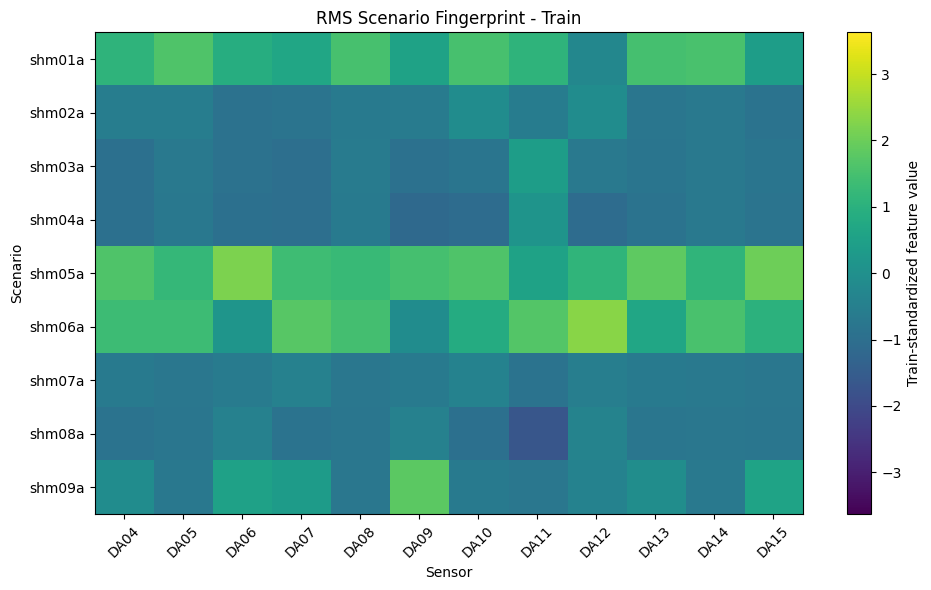

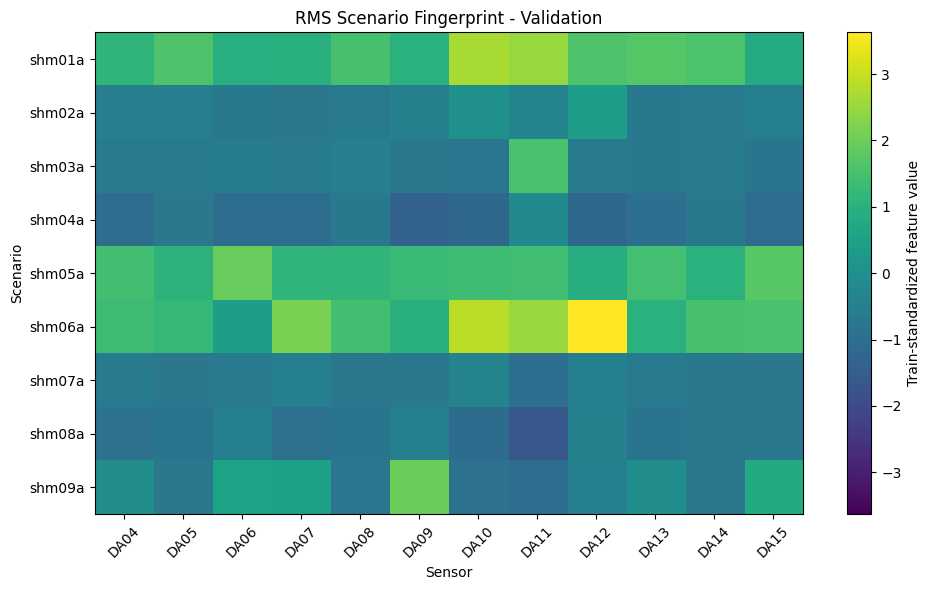

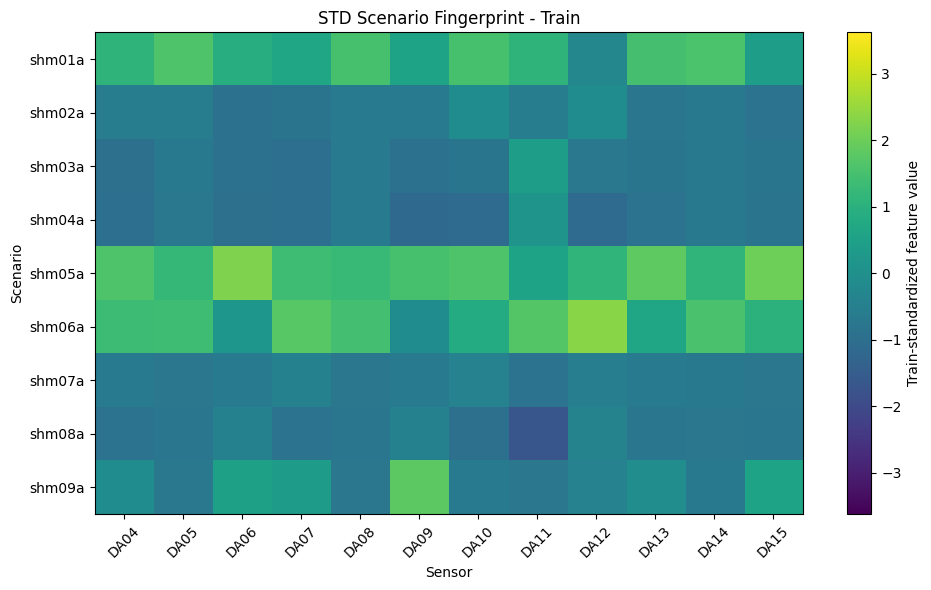

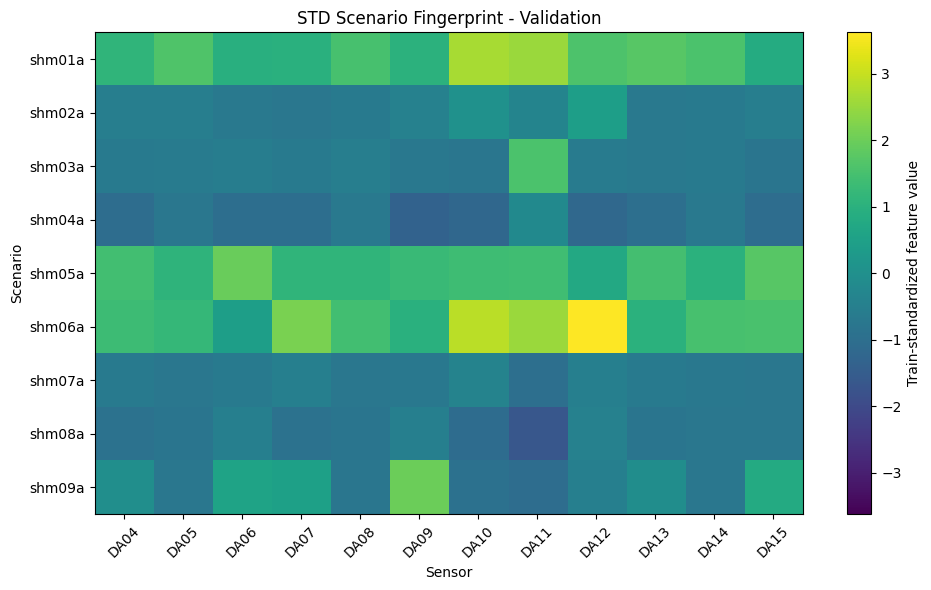

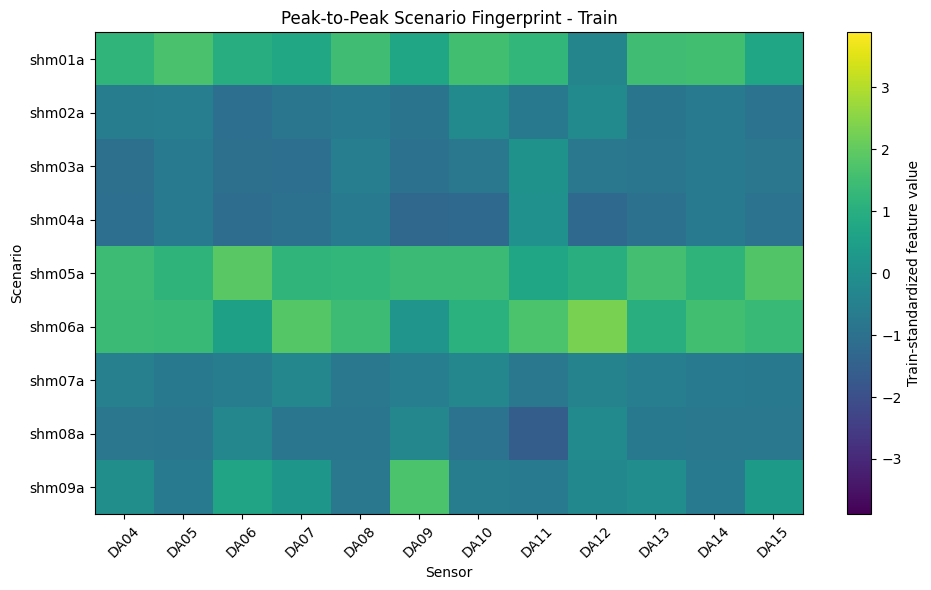

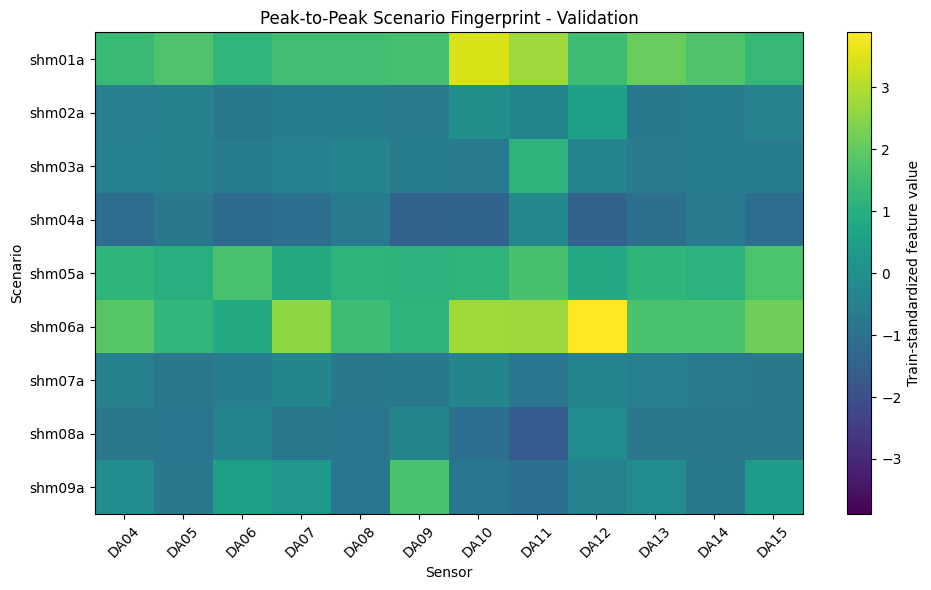

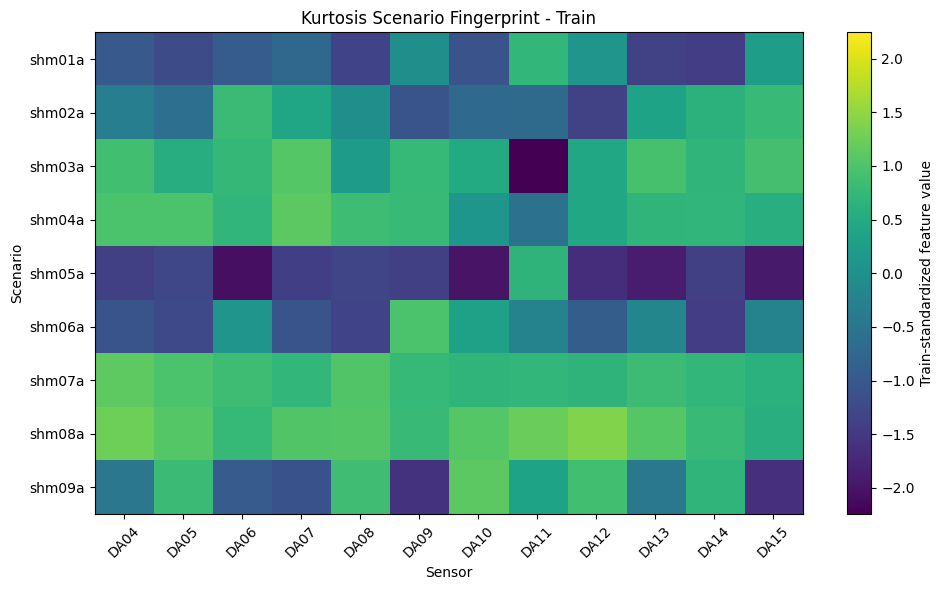

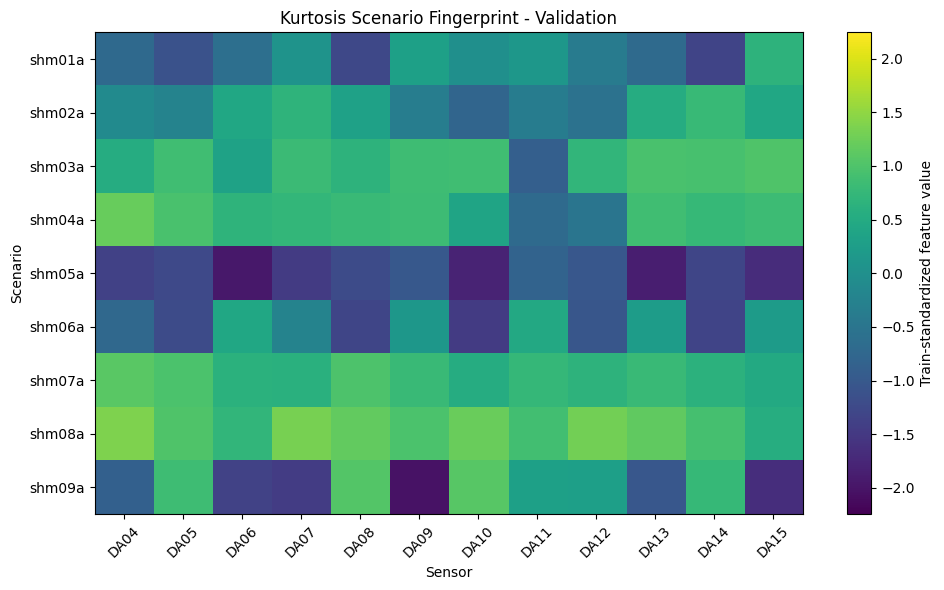

In [34]:
# ============================================================
# Plot Train and Validation fingerprint maps
# ============================================================

for feature_label in fingerprint_features.keys():

    train_z = fingerprint_maps[feature_label]["train_z"]
    val_z = fingerprint_maps[feature_label]["val_z"]

    # Same scale for Train and Validation
    vmax = max(
        np.abs(train_z.values).max(),
        np.abs(val_z.values).max()
    )

    # Train
    plt.figure(figsize=(10, 6))

    plt.imshow(
        train_z.values,
        aspect="auto",
        vmin=-vmax,
        vmax=vmax
    )

    plt.xticks(
        range(len(structural_sensors)),
        structural_sensors,
        rotation=45
    )

    plt.yticks(
        range(9),
        scenario_names
    )

    plt.colorbar(
        label="Train-standardized feature value"
    )

    plt.xlabel("Sensor")
    plt.ylabel("Scenario")
    plt.title(
        f"{feature_label} Scenario Fingerprint - Train"
    )

    plt.tight_layout()
    plt.show()


    # Validation
    plt.figure(figsize=(10, 6))

    plt.imshow(
        val_z.values,
        aspect="auto",
        vmin=-vmax,
        vmax=vmax
    )

    plt.xticks(
        range(len(structural_sensors)),
        structural_sensors,
        rotation=45
    )

    plt.yticks(
        range(9),
        scenario_names
    )

    plt.colorbar(
        label="Train-standardized feature value"
    )

    plt.xlabel("Sensor")
    plt.ylabel("Scenario")
    plt.title(
        f"{feature_label} Scenario Fingerprint - Validation"
    )

    plt.tight_layout()
    plt.show()

## 6.2 Train–Validation Scenario Fingerprint Matching

Each Validation scenario fingerprint is compared with all nine Train scenario
fingerprints.

Pearson correlation is used as the primary measure of pattern similarity across
the 12 structural sensors. Cosine similarity is also calculated as a
complementary measure.

A correct match occurs when a Validation scenario is most similar to the
corresponding Train scenario.

In [35]:
# ============================================================
# 6.2 Train–Validation Scenario Fingerprint Matching
# ============================================================

matching_results = {}


def cosine_similarity_1d(a, b):

    denominator = np.linalg.norm(a) * np.linalg.norm(b)

    if denominator == 0:
        return np.nan

    return np.dot(a, b) / denominator


for feature_label in fingerprint_features.keys():

    train_z = fingerprint_maps[feature_label]["train_z"].values
    val_z = fingerprint_maps[feature_label]["val_z"].values

    pearson_matrix = np.zeros((9, 9))
    cosine_matrix = np.zeros((9, 9))

    for val_i in range(9):

        for train_j in range(9):

            val_profile = val_z[val_i]
            train_profile = train_z[train_j]

            # Pearson correlation
            pearson_matrix[val_i, train_j] = np.corrcoef(
                val_profile,
                train_profile
            )[0, 1]

            # Cosine similarity
            cosine_matrix[val_i, train_j] = cosine_similarity_1d(
                val_profile,
                train_profile
            )

    pearson_df = pd.DataFrame(
        pearson_matrix,
        index=scenario_names,
        columns=scenario_names
    )

    cosine_df = pd.DataFrame(
        cosine_matrix,
        index=scenario_names,
        columns=scenario_names
    )

    # Best Train match for each Validation scenario
    pearson_best = np.argmax(
        pearson_matrix,
        axis=1
    )

    cosine_best = np.argmax(
        cosine_matrix,
        axis=1
    )

    pearson_accuracy = np.mean(
        pearson_best == np.arange(9)
    )

    cosine_accuracy = np.mean(
        cosine_best == np.arange(9)
    )

    matching_results[feature_label] = {
        "pearson": pearson_df,
        "cosine": cosine_df,
        "pearson_best": pearson_best,
        "cosine_best": cosine_best,
        "pearson_accuracy": pearson_accuracy,
        "cosine_accuracy": cosine_accuracy
    }

    print("\n", "=" * 60)
    print(feature_label)
    print("=" * 60)

    print(
        "Pearson matching accuracy:",
        f"{pearson_accuracy:.3f}",
        f"({np.sum(pearson_best == np.arange(9))}/9)"
    )

    print(
        "Cosine matching accuracy:",
        f"{cosine_accuracy:.3f}",
        f"({np.sum(cosine_best == np.arange(9))}/9)"
    )


RMS
Pearson matching accuracy: 0.778 (7/9)
Cosine matching accuracy: 1.000 (9/9)

STD
Pearson matching accuracy: 0.778 (7/9)
Cosine matching accuracy: 1.000 (9/9)

Peak-to-Peak
Pearson matching accuracy: 0.889 (8/9)
Cosine matching accuracy: 1.000 (9/9)

Kurtosis
Pearson matching accuracy: 1.000 (9/9)
Cosine matching accuracy: 0.778 (7/9)


In [36]:
# ============================================================
# Best scenario matches
# ============================================================

for feature_label in fingerprint_features.keys():

    result = matching_results[feature_label]

    match_table = pd.DataFrame({
        "validation_scenario": scenario_names,

        "pearson_best_match": [
            scenario_names[i]
            for i in result["pearson_best"]
        ],

        "pearson_correct": (
            result["pearson_best"] == np.arange(9)
        ),

        "cosine_best_match": [
            scenario_names[i]
            for i in result["cosine_best"]
        ],

        "cosine_correct": (
            result["cosine_best"] == np.arange(9)
        )
    })

    print("\n", feature_label)
    display(match_table)


 RMS


,validation_scenario,pearson_best_match,pearson_correct,cosine_best_match,cosine_correct
0,shm01a,shm03a,False,shm01a,True
1,shm02a,shm02a,True,shm02a,True
2,shm03a,shm03a,True,shm03a,True
3,shm04a,shm04a,True,shm04a,True
4,shm05a,shm05a,True,shm05a,True
5,shm06a,shm02a,False,shm06a,True
6,shm07a,shm07a,True,shm07a,True
7,shm08a,shm08a,True,shm08a,True
8,shm09a,shm09a,True,shm09a,True



 STD


,validation_scenario,pearson_best_match,pearson_correct,cosine_best_match,cosine_correct
0,shm01a,shm03a,False,shm01a,True
1,shm02a,shm02a,True,shm02a,True
2,shm03a,shm03a,True,shm03a,True
3,shm04a,shm04a,True,shm04a,True
4,shm05a,shm05a,True,shm05a,True
5,shm06a,shm02a,False,shm06a,True
6,shm07a,shm07a,True,shm07a,True
7,shm08a,shm08a,True,shm08a,True
8,shm09a,shm09a,True,shm09a,True



 Peak-to-Peak


,validation_scenario,pearson_best_match,pearson_correct,cosine_best_match,cosine_correct
0,shm01a,shm03a,False,shm01a,True
1,shm02a,shm02a,True,shm02a,True
2,shm03a,shm03a,True,shm03a,True
3,shm04a,shm04a,True,shm04a,True
4,shm05a,shm05a,True,shm05a,True
5,shm06a,shm06a,True,shm06a,True
6,shm07a,shm07a,True,shm07a,True
7,shm08a,shm08a,True,shm08a,True
8,shm09a,shm09a,True,shm09a,True



 Kurtosis


,validation_scenario,pearson_best_match,pearson_correct,cosine_best_match,cosine_correct
0,shm01a,shm01a,True,shm01a,True
1,shm02a,shm02a,True,shm02a,True
2,shm03a,shm03a,True,shm04a,False
3,shm04a,shm04a,True,shm04a,True
4,shm05a,shm05a,True,shm05a,True
5,shm06a,shm06a,True,shm01a,False
6,shm07a,shm07a,True,shm07a,True
7,shm08a,shm08a,True,shm08a,True
8,shm09a,shm09a,True,shm09a,True


## 6.3 Scenario Fingerprint Uniqueness Margin

For each Validation scenario, the similarity to the corresponding Train
scenario is compared with the highest similarity to any incorrect Train
scenario.

The uniqueness margin is defined as:

Margin = Correct-scenario similarity - Best incorrect-scenario similarity

A positive margin indicates that the correct Train scenario is the closest
match. Larger positive margins indicate a more distinctive scenario
fingerprint.

In [37]:
# ============================================================
# 6.3 Scenario Fingerprint Uniqueness Margin
# ============================================================

margin_results = []

for feature_label in fingerprint_features.keys():

    pearson_matrix = (
        matching_results[feature_label]["pearson"].values
    )

    cosine_matrix = (
        matching_results[feature_label]["cosine"].values
    )

    for scenario_i in range(9):

        # ----------------------------------------------------
        # Pearson
        # ----------------------------------------------------

        pearson_correct = pearson_matrix[
            scenario_i,
            scenario_i
        ]

        pearson_wrong = np.delete(
            pearson_matrix[scenario_i],
            scenario_i
        )

        pearson_best_wrong = np.max(
            pearson_wrong
        )

        pearson_margin = (
            pearson_correct -
            pearson_best_wrong
        )

        # ----------------------------------------------------
        # Cosine
        # ----------------------------------------------------

        cosine_correct = cosine_matrix[
            scenario_i,
            scenario_i
        ]

        cosine_wrong = np.delete(
            cosine_matrix[scenario_i],
            scenario_i
        )

        cosine_best_wrong = np.max(
            cosine_wrong
        )

        cosine_margin = (
            cosine_correct -
            cosine_best_wrong
        )

        margin_results.append({
            "feature": feature_label,
            "scenario": scenario_names[scenario_i],

            "pearson_correct_similarity":
                pearson_correct,

            "pearson_best_wrong_similarity":
                pearson_best_wrong,

            "pearson_margin":
                pearson_margin,

            "cosine_correct_similarity":
                cosine_correct,

            "cosine_best_wrong_similarity":
                cosine_best_wrong,

            "cosine_margin":
                cosine_margin
        })


margin_df = pd.DataFrame(
    margin_results
)

display(
    margin_df.round(3)
)

,feature,scenario,pearson_correct_similarity,pearson_best_wrong_similarity,pearson_margin,cosine_correct_similarity,cosine_best_wrong_similarity,cosine_margin
0,RMS,shm01a,0.416,0.618,-0.202,0.890,0.857,0.033
1,RMS,shm02a,0.902,0.367,0.535,0.949,0.826,0.122
2,RMS,shm03a,0.953,0.900,0.054,0.882,0.826,0.056
3,RMS,shm04a,0.967,0.843,0.125,0.994,0.967,0.028
4,RMS,shm05a,0.717,0.399,0.318,0.980,0.852,0.128
5,RMS,shm06a,0.698,0.749,-0.051,0.933,0.790,0.142
6,RMS,shm07a,0.973,0.470,0.504,0.999,0.943,0.056
7,RMS,shm08a,0.994,0.531,0.463,0.999,0.941,0.058
8,RMS,shm09a,0.993,0.534,0.460,0.993,0.273,0.721
9,STD,shm01a,0.414,0.626,-0.212,0.890,0.857,0.033


In [38]:
for feature_label in fingerprint_features.keys():

    print("\n", "=" * 60)
    print(feature_label)
    print("=" * 60)

    feature_margin = margin_df[
        margin_df["feature"] == feature_label
    ][[
        "scenario",
        "pearson_correct_similarity",
        "pearson_best_wrong_similarity",
        "pearson_margin",
        "cosine_correct_similarity",
        "cosine_best_wrong_similarity",
        "cosine_margin"
    ]]

    display(
        feature_margin.round(3)
    )


RMS


,scenario,pearson_correct_similarity,pearson_best_wrong_similarity,pearson_margin,cosine_correct_similarity,cosine_best_wrong_similarity,cosine_margin
0,shm01a,0.416,0.618,-0.202,0.890,0.857,0.033
1,shm02a,0.902,0.367,0.535,0.949,0.826,0.122
2,shm03a,0.953,0.900,0.054,0.882,0.826,0.056
3,shm04a,0.967,0.843,0.125,0.994,0.967,0.028
4,shm05a,0.717,0.399,0.318,0.980,0.852,0.128
5,shm06a,0.698,0.749,-0.051,0.933,0.790,0.142
6,shm07a,0.973,0.470,0.504,0.999,0.943,0.056
7,shm08a,0.994,0.531,0.463,0.999,0.941,0.058
8,shm09a,0.993,0.534,0.460,0.993,0.273,0.721



STD


,scenario,pearson_correct_similarity,pearson_best_wrong_similarity,pearson_margin,cosine_correct_similarity,cosine_best_wrong_similarity,cosine_margin
9,shm01a,0.414,0.626,-0.212,0.890,0.857,0.033
10,shm02a,0.903,0.363,0.540,0.949,0.827,0.122
11,shm03a,0.954,0.896,0.058,0.881,0.824,0.057
12,shm04a,0.970,0.847,0.123,0.994,0.967,0.027
13,shm05a,0.700,0.388,0.312,0.979,0.859,0.120
14,shm06a,0.698,0.750,-0.051,0.933,0.791,0.142
15,shm07a,0.974,0.471,0.503,0.999,0.942,0.057
16,shm08a,0.995,0.533,0.462,0.999,0.941,0.058
17,shm09a,0.994,0.536,0.458,0.994,0.273,0.721



Peak-to-Peak


,scenario,pearson_correct_similarity,pearson_best_wrong_similarity,pearson_margin,cosine_correct_similarity,cosine_best_wrong_similarity,cosine_margin
18,shm01a,0.415,0.481,-0.066,0.904,0.894,0.010
19,shm02a,0.833,0.572,0.261,0.917,0.811,0.106
20,shm03a,0.875,0.833,0.041,0.844,0.836,0.008
21,shm04a,0.975,0.803,0.173,0.996,0.977,0.019
22,shm05a,0.398,0.344,0.054,0.969,0.888,0.080
23,shm06a,0.739,0.668,0.070,0.961,0.857,0.105
24,shm07a,0.963,0.447,0.516,0.997,0.940,0.057
25,shm08a,0.993,0.539,0.454,0.999,0.905,0.094
26,shm09a,0.990,0.599,0.391,0.985,0.454,0.531



Kurtosis


,scenario,pearson_correct_similarity,pearson_best_wrong_similarity,pearson_margin,cosine_correct_similarity,cosine_best_wrong_similarity,cosine_margin
27,shm01a,0.770,0.662,0.108,0.845,0.771,0.075
28,shm02a,0.897,0.499,0.398,0.846,0.389,0.457
29,shm03a,0.910,0.716,0.194,0.865,0.899,-0.034
30,shm04a,0.814,0.741,0.073,0.913,0.795,0.118
31,shm05a,0.740,0.497,0.244,0.951,0.754,0.197
32,shm06a,0.555,0.530,0.025,0.698,0.700,-0.002
33,shm07a,0.918,0.434,0.484,0.995,0.970,0.025
34,shm08a,0.772,0.378,0.394,0.989,0.973,0.015
35,shm09a,0.978,0.445,0.533,0.965,0.362,0.603


# 7. Cross-Sensor Relational Fingerprints

This section investigates whether each scenario has a stable pattern of
relationships among the 12 structural sensors.

Rather than comparing the absolute statistical feature levels, we examine
how the feature values of different sensors co-vary across windows.

## 7.1 RMS Cross-Sensor Correlation Structure

In [39]:
# ============================================================
# 7.1 RMS Cross-Sensor Correlation Structure
# ============================================================

rms_relation_matrices = {
    "Train": {},
    "Validation": {}
}

for split_name, feature_df in [
    ("Train", train_feature_df),
    ("Validation", val_feature_df)
]:

    for scenario_i in range(9):

        scenario_df = feature_df[
            feature_df["scenario"] == scenario_i
        ]

        # windows x sensors
        rms_matrix = (
            scenario_df[
                scenario_df["sensor"].isin(structural_sensors)
            ]
            .pivot(
                index="window_index",
                columns="sensor",
                values="rms"
            )
            .reindex(columns=structural_sensors)
        )

        # 12 x 12 Spearman correlation matrix
        corr_matrix = rms_matrix.corr(
            method="spearman"
        )

        rms_relation_matrices[split_name][scenario_i] = corr_matrix


print(
    "Train matrices:",
    len(rms_relation_matrices["Train"])
)

print(
    "Validation matrices:",
    len(rms_relation_matrices["Validation"])
)

print(
    "Matrix shape:",
    rms_relation_matrices["Train"][0].shape
)

Train matrices: 9
Validation matrices: 9
Matrix shape: (12, 12)


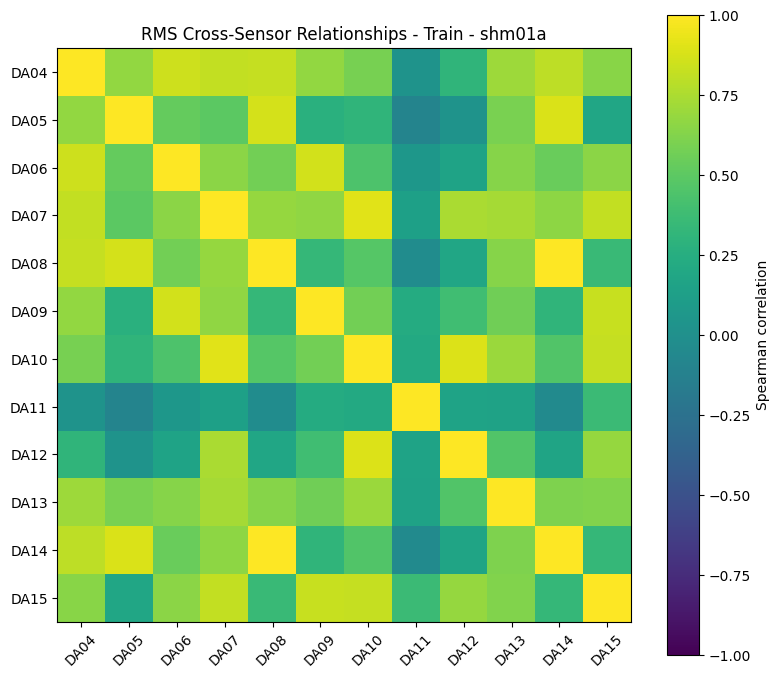

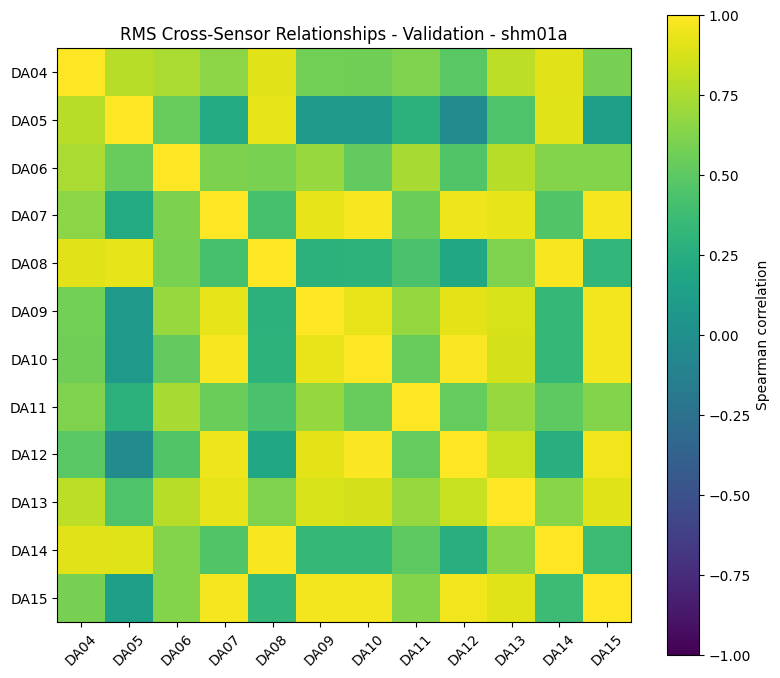

In [40]:
# ============================================================
# Example: shm01a relational fingerprint
# ============================================================

scenario_i = 0

train_corr = rms_relation_matrices[
    "Train"
][scenario_i]

val_corr = rms_relation_matrices[
    "Validation"
][scenario_i]


plt.figure(figsize=(8, 7))

plt.imshow(
    train_corr.values,
    vmin=-1,
    vmax=1
)

plt.xticks(
    range(12),
    structural_sensors,
    rotation=45
)

plt.yticks(
    range(12),
    structural_sensors
)

plt.colorbar(
    label="Spearman correlation"
)

plt.title(
    "RMS Cross-Sensor Relationships - Train - shm01a"
)

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 7))

plt.imshow(
    val_corr.values,
    vmin=-1,
    vmax=1
)

plt.xticks(
    range(12),
    structural_sensors,
    rotation=45
)

plt.yticks(
    range(12),
    structural_sensors
)

plt.colorbar(
    label="Spearman correlation"
)

plt.title(
    "RMS Cross-Sensor Relationships - Validation - shm01a"
)

plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# 7.2 Train-Validation Stability of RMS Relational Fingerprints
# ============================================================

upper_idx = np.triu_indices(
    len(structural_sensors),
    k=1
)

relation_stability_rows = []

for scenario_i in range(9):

    train_corr = rms_relation_matrices[
        "Train"
    ][scenario_i].values

    val_corr = rms_relation_matrices[
        "Validation"
    ][scenario_i].values

    # 66 unique sensor-pair relationships
    train_vec = train_corr[upper_idx]
    val_vec = val_corr[upper_idx]

    # Similarity of the relational pattern
    pearson_similarity = np.corrcoef(
        train_vec,
        val_vec
    )[0, 1]

    # Absolute change in correlation strengths
    mae = np.mean(
        np.abs(train_vec - val_vec)
    )

    relation_stability_rows.append({
        "scenario": scenario_names[scenario_i],
        "pearson_pattern_similarity": pearson_similarity,
        "mean_absolute_difference": mae
    })


relation_stability_df = pd.DataFrame(
    relation_stability_rows
)

display(
    relation_stability_df.round(3)
)

,scenario,pearson_pattern_similarity,mean_absolute_difference
0,shm01a,0.664,0.191
1,shm02a,0.820,0.264
2,shm03a,0.733,0.202
3,shm04a,0.752,0.161
4,shm05a,0.796,0.123
5,shm06a,0.726,0.343
6,shm07a,0.835,0.108
7,shm08a,0.869,0.074
8,shm09a,0.970,0.182


## 7.3 Train–Validation Matching of RMS Relational Fingerprints

Each Validation scenario is represented by the 66 unique pairwise
cross-sensor RMS correlations.

The relational fingerprint of each Validation scenario is compared with all
nine Train scenario fingerprints.

Pearson correlation measures similarity in the pattern of sensor
relationships, while mean absolute error measures the absolute difference
between the correlation values.


In [42]:
# ============================================================
# 7.3 Train-Validation Matching of RMS Relational Fingerprints
# ============================================================

pearson_relation_matrix = np.zeros((9, 9))
mae_relation_matrix = np.zeros((9, 9))

for val_i in range(9):

    val_corr = rms_relation_matrices[
        "Validation"
    ][val_i].values

    val_vec = val_corr[upper_idx]

    for train_j in range(9):

        train_corr = rms_relation_matrices[
            "Train"
        ][train_j].values

        train_vec = train_corr[upper_idx]

        # Pattern similarity
        pearson_relation_matrix[val_i, train_j] = np.corrcoef(
            val_vec,
            train_vec
        )[0, 1]

        # Absolute difference in correlation strengths
        mae_relation_matrix[val_i, train_j] = np.mean(
            np.abs(val_vec - train_vec)
        )

In [43]:
pearson_relation_df = pd.DataFrame(
    pearson_relation_matrix,
    index=scenario_names,
    columns=scenario_names
)

mae_relation_df = pd.DataFrame(
    mae_relation_matrix,
    index=scenario_names,
    columns=scenario_names
)

print("Pearson relational similarity")
display(pearson_relation_df.round(3))

print("MAE relational distance")
display(mae_relation_df.round(3))

Pearson relational similarity


,shm01a,shm02a,shm03a,shm04a,shm05a,shm06a,shm07a,shm08a,shm09a
shm01a,0.664,0.560,0.728,0.600,0.556,0.800,0.634,0.455,0.315
shm02a,0.285,0.820,0.615,0.584,0.139,0.271,0.594,0.393,0.310
shm03a,0.262,0.608,0.733,0.759,0.098,0.396,0.616,0.322,0.355
shm04a,0.427,0.686,0.690,0.752,0.389,0.408,0.762,0.458,0.463
shm05a,0.808,0.018,0.228,0.411,0.796,0.375,0.327,0.482,0.319
shm06a,0.487,0.502,0.668,0.508,0.442,0.726,0.580,0.433,0.277
shm07a,0.337,0.498,0.627,0.522,0.189,0.389,0.835,0.645,0.756
shm08a,0.533,0.405,0.658,0.538,0.375,0.429,0.813,0.869,0.681
shm09a,0.432,0.291,0.487,0.491,0.410,0.308,0.792,0.746,0.970


MAE relational distance


,shm01a,shm02a,shm03a,shm04a,shm05a,shm06a,shm07a,shm08a,shm09a
shm01a,0.191,0.233,0.145,0.203,0.206,0.327,0.184,0.195,0.319
shm02a,0.401,0.264,0.409,0.332,0.500,0.386,0.365,0.409,0.402
shm03a,0.254,0.178,0.202,0.164,0.332,0.311,0.176,0.235,0.266
shm04a,0.251,0.198,0.212,0.161,0.297,0.341,0.183,0.239,0.297
shm05a,0.200,0.309,0.228,0.281,0.123,0.418,0.229,0.169,0.341
shm06a,0.223,0.248,0.155,0.215,0.227,0.343,0.202,0.209,0.337
shm07a,0.220,0.200,0.180,0.207,0.269,0.325,0.108,0.143,0.195
shm08a,0.177,0.226,0.155,0.208,0.223,0.340,0.109,0.074,0.237
shm09a,0.404,0.412,0.424,0.373,0.457,0.418,0.321,0.401,0.182


In [44]:
# Highest Pearson = best match
pearson_best = np.argmax(
    pearson_relation_matrix,
    axis=1
)

# Lowest MAE = best match
mae_best = np.argmin(
    mae_relation_matrix,
    axis=1
)

pearson_accuracy = np.mean(
    pearson_best == np.arange(9)
)

mae_accuracy = np.mean(
    mae_best == np.arange(9)
)

print(
    "Pearson relational matching accuracy:",
    f"{pearson_accuracy:.3f}",
    f"({np.sum(pearson_best == np.arange(9))}/9)"
)

print(
    "MAE relational matching accuracy:",
    f"{mae_accuracy:.3f}",
    f"({np.sum(mae_best == np.arange(9))}/9)"
)

Pearson relational matching accuracy: 0.556 (5/9)
MAE relational matching accuracy: 0.667 (6/9)


# 8. Window-Level Statistical Classification Diagnostic

This diagnostic examines whether simple window-level statistical features
already contain sufficient information for scenario discrimination.

For each window, RMS, STD, Peak-to-Peak, and Kurtosis from DA04–DA15 are
combined into a 48-dimensional feature vector.

A simple Logistic Regression classifier is trained on the Chronological Train
split and evaluated on Validation.

This analysis is exploratory and is not used as evidence of acquisition
leakage by itself.

In [45]:
# ============================================================
# 8.1 Build window-level statistical feature vectors
# ============================================================

stat_features = [
    "rms",
    "std",
    "peak_to_peak",
    "kurtosis"
]


def build_window_feature_matrix(feature_df):

    df = feature_df[
        feature_df["sensor"].isin(structural_sensors)
    ].copy()

    wide_df = df.pivot(
        index=["scenario", "window_index"],
        columns="sensor",
        values=stat_features
    )

    # Keep a fixed feature/sensor order
    desired_columns = [
        (feature, sensor)
        for feature in stat_features
        for sensor in structural_sensors
    ]

    wide_df = wide_df[
        desired_columns
    ]

    X = wide_df.values

    y = (
        wide_df.index
        .get_level_values("scenario")
        .to_numpy()
    )

    return X, y


X_train_stats, y_train_stats = build_window_feature_matrix(
    train_feature_df
)

X_val_stats, y_val_stats = build_window_feature_matrix(
    val_feature_df
)


print("Train:", X_train_stats.shape)
print("Validation:", X_val_stats.shape)

assert X_train_stats.shape[1] == 48
assert X_val_stats.shape[1] == 48

assert np.isfinite(X_train_stats).all()
assert np.isfinite(X_val_stats).all()

Train: (1018, 48)
Validation: (325, 48)


In [46]:
# ============================================================
# 8.2 Train-only feature scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler_stats = StandardScaler()

X_train_stats_scaled = scaler_stats.fit_transform(
    X_train_stats
)

X_val_stats_scaled = scaler_stats.transform(
    X_val_stats
)

In [47]:
# ============================================================
# 8.3 Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

lr_stats = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_stats.fit(
    X_train_stats_scaled,
    y_train_stats
)


train_pred = lr_stats.predict(
    X_train_stats_scaled
)

val_pred = lr_stats.predict(
    X_val_stats_scaled
)


train_acc = accuracy_score(
    y_train_stats,
    train_pred
)

val_acc = accuracy_score(
    y_val_stats,
    val_pred
)

train_f1 = f1_score(
    y_train_stats,
    train_pred,
    average="macro"
)

val_f1 = f1_score(
    y_val_stats,
    val_pred,
    average="macro"
)


print(
    "Train Accuracy:",
    round(train_acc, 4)
)

print(
    "Train Macro-F1:",
    round(train_f1, 4)
)

print()

print(
    "Validation Accuracy:",
    round(val_acc, 4)
)

print(
    "Validation Macro-F1:",
    round(val_f1, 4)
)

Train Accuracy: 0.9853
Train Macro-F1: 0.9837

Validation Accuracy: 0.9415
Validation Macro-F1: 0.9026


In [48]:
print(
    classification_report(
        y_val_stats,
        val_pred,
        target_names=scenario_names,
        digits=3
    )
)

              precision    recall  f1-score   support

      shm01a      0.941     0.762     0.842        21
      shm02a      0.947     0.857     0.900        21
      shm03a      1.000     0.571     0.727        21
      shm04a      0.750     1.000     0.857        21
      shm05a      1.000     0.952     0.976        21
      shm06a      0.762     1.000     0.865        16
      shm07a      0.944     0.985     0.964        68
      shm08a      0.986     1.000     0.993        68
      shm09a      1.000     1.000     1.000        68

    accuracy                          0.942       325
   macro avg      0.926     0.903     0.903       325
weighted avg      0.950     0.942     0.939       325



## 8.4 Single-Feature Statistical Classification Diagnostic

Three separate Logistic Regression models are evaluated using only:

- RMS across DA04–DA15
- Peak-to-Peak across DA04–DA15
- Kurtosis across DA04–DA15

Each model therefore receives only 12 input features per window.

The purpose is to determine which type of simple statistical information
contributes most strongly to scenario discrimination.

In [49]:
# ============================================================
# 8.4 Single-Feature Statistical Classification Diagnostic
# ============================================================

single_features = {
    "RMS": "rms",
    "Peak-to-Peak": "peak_to_peak",
    "Kurtosis": "kurtosis"
}


def build_single_feature_matrix(feature_df, feature_name):

    df = feature_df[
        feature_df["sensor"].isin(structural_sensors)
    ]

    wide_df = (
        df.pivot(
            index=["scenario", "window_index"],
            columns="sensor",
            values=feature_name
        )
        .reindex(columns=structural_sensors)
    )

    X = wide_df.values

    y = (
        wide_df.index
        .get_level_values("scenario")
        .to_numpy()
    )

    return X, y

In [50]:
single_feature_results = []

for label, feature_name in single_features.items():

    # ----------------------------------------
    # Build data
    # ----------------------------------------

    X_train, y_train = build_single_feature_matrix(
        train_feature_df,
        feature_name
    )

    X_val, y_val = build_single_feature_matrix(
        val_feature_df,
        feature_name
    )

    # ----------------------------------------
    # Train-only scaling
    # ----------------------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_val_scaled = scaler.transform(
        X_val
    )

    # ----------------------------------------
    # Logistic Regression
    # ----------------------------------------

    model = LogisticRegression(
        max_iter=5000,
        random_state=42
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    train_pred = model.predict(
        X_train_scaled
    )

    val_pred = model.predict(
        X_val_scaled
    )

    # ----------------------------------------
    # Metrics
    # ----------------------------------------

    train_acc = accuracy_score(
        y_train,
        train_pred
    )

    train_f1 = f1_score(
        y_train,
        train_pred,
        average="macro"
    )

    val_acc = accuracy_score(
        y_val,
        val_pred
    )

    val_f1 = f1_score(
        y_val,
        val_pred,
        average="macro"
    )

    single_feature_results.append({
        "feature": label,
        "n_features": X_train.shape[1],
        "train_accuracy": train_acc,
        "train_macro_f1": train_f1,
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1
    })

    print("\n", "=" * 60)
    print(label)
    print("=" * 60)

    print(
        "Train Accuracy:",
        round(train_acc, 4)
    )

    print(
        "Train Macro-F1:",
        round(train_f1, 4)
    )

    print(
        "Validation Accuracy:",
        round(val_acc, 4)
    )

    print(
        "Validation Macro-F1:",
        round(val_f1, 4)
    )

    print()

    print(
        classification_report(
            y_val,
            val_pred,
            target_names=scenario_names,
            digits=3
        )
    )


RMS
Train Accuracy: 0.9627
Train Macro-F1: 0.9592
Validation Accuracy: 0.9169
Validation Macro-F1: 0.8845

              precision    recall  f1-score   support

      shm01a      0.857     0.857     0.857        21
      shm02a      1.000     0.429     0.600        21
      shm03a      0.895     0.810     0.850        21
      shm04a      0.955     1.000     0.977        21
      shm05a      1.000     0.857     0.923        21
      shm06a      0.842     1.000     0.914        16
      shm07a      0.850     1.000     0.919        68
      shm08a      0.917     0.971     0.943        68
      shm09a      1.000     0.956     0.977        68

    accuracy                          0.917       325
   macro avg      0.924     0.875     0.884       325
weighted avg      0.924     0.917     0.911       325


Peak-to-Peak
Train Accuracy: 0.9538
Train Macro-F1: 0.9524
Validation Accuracy: 0.9262
Validation Macro-F1: 0.8948

              precision    recall  f1-score   support

      shm01a   

In [51]:
single_feature_summary = pd.DataFrame(
    single_feature_results
)

display(
    single_feature_summary.round(4)
)

,feature,n_features,train_accuracy,train_macro_f1,val_accuracy,val_macro_f1
0,RMS,12,0.9627,0.9592,0.9169,0.8845
1,Peak-to-Peak,12,0.9538,0.9524,0.9262,0.8948
2,Kurtosis,12,0.7200,0.7590,0.7077,0.7014


## 8.5 Amplitude-Removed Statistical Classification Diagnostic

To examine whether scenario discrimination depends primarily on signal
amplitude, each window-sensor signal is conceptually standardized to zero mean
and unit variance.

After this transformation, RMS and STD become approximately constant and no
longer contain discriminative amplitude information.

The remaining statistical information is represented by:

- normalized Peak-to-Peak: Peak-to-Peak / STD
- Kurtosis

This produces 24 amplitude-invariant features per window across DA04–DA15.

In [52]:
# ============================================================
# 8.5 Amplitude-Removed Statistical Features
# ============================================================

train_ampfree_df = train_feature_df.copy()
val_ampfree_df = val_feature_df.copy()

eps = 1e-12

train_ampfree_df["norm_peak_to_peak"] = (
    train_ampfree_df["peak_to_peak"] /
    (train_ampfree_df["std"] + eps)
)

val_ampfree_df["norm_peak_to_peak"] = (
    val_ampfree_df["peak_to_peak"] /
    (val_ampfree_df["std"] + eps)
)

print(
    train_ampfree_df[
        ["norm_peak_to_peak", "kurtosis"]
    ].describe()
)

       norm_peak_to_peak      kurtosis
count       13234.000000  13234.000000
mean            5.436888      2.843058
std             1.052894      7.940269
min             3.085134      1.508835
25%             4.922901      2.335948
50%             5.445276      2.655615
75%             5.904495      2.896279
max            22.881304    514.993164


In [53]:
# ============================================================
# Build 24-dimensional amplitude-free feature vectors
# ============================================================

ampfree_features = [
    "norm_peak_to_peak",
    "kurtosis"
]


def build_ampfree_matrix(feature_df):

    df = feature_df[
        feature_df["sensor"].isin(structural_sensors)
    ]

    wide_df = df.pivot(
        index=["scenario", "window_index"],
        columns="sensor",
        values=ampfree_features
    )

    desired_columns = [
        (feature, sensor)
        for feature in ampfree_features
        for sensor in structural_sensors
    ]

    wide_df = wide_df[
        desired_columns
    ]

    X = wide_df.values

    y = (
        wide_df.index
        .get_level_values("scenario")
        .to_numpy()
    )

    return X, y


X_train_ampfree, y_train_ampfree = build_ampfree_matrix(
    train_ampfree_df
)

X_val_ampfree, y_val_ampfree = build_ampfree_matrix(
    val_ampfree_df
)

print("Train:", X_train_ampfree.shape)
print("Validation:", X_val_ampfree.shape)

assert X_train_ampfree.shape[1] == 24
assert X_val_ampfree.shape[1] == 24

assert np.isfinite(X_train_ampfree).all()
assert np.isfinite(X_val_ampfree).all()

Train: (1018, 24)
Validation: (325, 24)


In [55]:
# ============================================================
# Logistic Regression after amplitude removal
# ============================================================

ampfree_scaler = StandardScaler()

X_train_ampfree_scaled = ampfree_scaler.fit_transform(X_train_ampfree)

X_val_ampfree_scaled = ampfree_scaler.transform(X_val_ampfree)


lr_ampfree = LogisticRegression(max_iter=5000,random_state=42)
lr_ampfree.fit(X_train_ampfree_scaled,y_train_ampfree)


train_ampfree_pred = lr_ampfree.predict(X_train_ampfree_scaled)
val_ampfree_pred = lr_ampfree.predict(X_val_ampfree_scaled)


train_ampfree_acc = accuracy_score(y_train_ampfree,train_ampfree_pred)
train_ampfree_f1 = f1_score(y_train_ampfree,train_ampfree_pred,average="macro")

val_ampfree_acc = accuracy_score(y_val_ampfree,val_ampfree_pred)
val_ampfree_f1 = f1_score(y_val_ampfree,val_ampfree_pred,average="macro")


print("Train Accuracy:", round(train_ampfree_acc, 4))
print("Train Macro-F1:", round(train_ampfree_f1, 4))
print()
print("Validation Accuracy:", round(val_ampfree_acc, 4))
print("Validation Macro-F1:",round(val_ampfree_f1, 4))
print()
print(classification_report(y_val_ampfree,val_ampfree_pred,target_names=scenario_names,digits=3))

Train Accuracy: 0.7554
Train Macro-F1: 0.7978

Validation Accuracy: 0.7262
Validation Macro-F1: 0.7226

              precision    recall  f1-score   support

      shm01a      0.952     0.952     0.952        21
      shm02a      0.889     0.762     0.821        21
      shm03a      0.636     0.333     0.438        21
      shm04a      0.333     0.286     0.308        21
      shm05a      0.913     1.000     0.955        21
      shm06a      1.000     0.750     0.857        16
      shm07a      0.554     0.603     0.577        68
      shm08a      0.605     0.676     0.639        68
      shm09a      0.931     0.985     0.957        68

    accuracy                          0.726       325
   macro avg      0.757     0.705     0.723       325
weighted avg      0.727     0.726     0.721       325



In [58]:
print(type(train_selected))

if isinstance(train_selected, dict):
    print(train_selected.keys())

<class 'dict'>
dict_keys(['shm01a', 'shm02a', 'shm03a', 'shm04a', 'shm05a', 'shm06a', 'shm07a', 'shm08a', 'shm09a'])


In [59]:
# ============================================================
# 9.1 Direct Amplitude Audit
# Pre-normalization processed signals
# ============================================================

amplitude_rows = []

amplitude_sensors = [
    "DA04", "DA05", "DA06", "DA07",
    "DA08", "DA09", "DA10", "DA11",
    "DA12", "DA13", "DA14", "DA15"
]

for split_name, split_data in [
    ("Train", train_selected),
    ("Validation", val_selected)
]:

    for scenario_name in scenario_names:

        # Use scenario name as dictionary key
        x_scenario = split_data[scenario_name]

        for sensor_i, sensor_name in enumerate(amplitude_sensors):

            x = x_scenario[:, sensor_i]

            amplitude_rows.append({
                "split": split_name,
                "scenario": scenario_name,
                "sensor": sensor_name,

                "mean": np.mean(x),

                "rms": np.sqrt(np.mean(x ** 2)),

                "median_abs": np.median(
                    np.abs(x)
                ),

                "p95_abs": np.percentile(
                    np.abs(x), 95
                ),

                "max_abs": np.max(
                    np.abs(x)
                ),

                "peak_to_peak": np.ptp(x)
            })


amplitude_df = pd.DataFrame(amplitude_rows)

print("Rows:", len(amplitude_df))
display(amplitude_df.head(15))

Rows: 216


,split,scenario,sensor,mean,rms,median_abs,p95_abs,max_abs,peak_to_peak
0,Train,shm01a,DA04,4.320043e-07,0.000143,0.000125,0.000240,0.000390,0.000773
1,Train,shm01a,DA05,4.119982e-06,0.000872,0.000837,0.001334,0.002087,0.004098
2,Train,shm01a,DA06,3.156995e-07,0.000130,0.000104,0.000232,0.000395,0.000769
3,Train,shm01a,DA07,4.790927e-07,0.000095,0.000076,0.000172,0.000398,0.000747
4,Train,shm01a,DA08,2.908334e-06,0.000895,0.000874,0.001342,0.002013,0.004024
5,Train,shm01a,DA09,5.072162e-07,0.000101,0.000072,0.000192,0.000416,0.000772
6,Train,shm01a,DA10,1.098604e-06,0.000088,0.000064,0.000166,0.000327,0.000653
7,Train,shm01a,DA11,1.119301e-06,0.000128,0.000082,0.000243,0.000831,0.001579
8,Train,shm01a,DA12,-2.502554e-07,0.000056,0.000038,0.000111,0.000224,0.000447
9,Train,shm01a,DA13,1.737904e-06,0.000229,0.000192,0.000396,0.000749,0.001458


In [60]:
# ============================================================
# Scenario x Sensor RMS
# ============================================================

train_rms_table = (
    amplitude_df[
        amplitude_df["split"] == "Train"
    ]
    .pivot(
        index="scenario",
        columns="sensor",
        values="rms"
    )
    .reindex(
        index=scenario_names,
        columns=amplitude_sensors
    )
)

val_rms_table = (
    amplitude_df[
        amplitude_df["split"] == "Validation"
    ]
    .pivot(
        index="scenario",
        columns="sensor",
        values="rms"
    )
    .reindex(
        index=scenario_names,
        columns=amplitude_sensors
    )
)

print("TRAIN RMS")
display(train_rms_table)

print("VALIDATION RMS")
display(val_rms_table)

TRAIN RMS


sensor,DA04,DA05,DA06,DA07,DA08,DA09,DA10,DA11,DA12,DA13,DA14,DA15
scenario,,,,,,,,,,,,
shm01a,0.000143,0.000872,0.000130,0.000095,0.000895,0.000101,0.000088,0.000128,0.000056,0.000229,0.000884,0.000127
shm02a,0.000055,0.000131,0.000034,0.000040,0.000099,0.000063,0.000055,0.000070,0.000059,0.000058,0.000078,0.000060
shm03a,0.000036,0.000088,0.000041,0.000037,0.000116,0.000060,0.000045,0.000101,0.000056,0.000058,0.000081,0.000072
shm04a,0.000033,0.000068,0.000032,0.000034,0.000089,0.000045,0.000036,0.000088,0.000039,0.000049,0.000077,0.000060
shm05a,0.000172,0.000725,0.000202,0.000122,0.000797,0.000134,0.000092,0.000105,0.000087,0.000254,0.000725,0.000212
shm06a,0.000158,0.000798,0.000092,0.000136,0.000878,0.000083,0.000077,0.000139,0.000110,0.000169,0.000879,0.000161
shm07a,0.000054,0.000070,0.000054,0.000056,0.000069,0.000070,0.000052,0.000069,0.000058,0.000073,0.000076,0.000068
shm08a,0.000038,0.000056,0.000062,0.000038,0.000052,0.000073,0.005334,0.000044,0.000054,0.000057,0.000058,0.000067
shm09a,0.000082,0.000079,0.000116,0.000087,0.000072,0.000150,0.000047,0.000074,0.000057,0.000114,0.000077,0.000140


VALIDATION RMS


sensor,DA04,DA05,DA06,DA07,DA08,DA09,DA10,DA11,DA12,DA13,DA14,DA15
scenario,,,,,,,,,,,,
shm01a,0.000143,0.000843,0.000132,0.000111,0.000877,0.000117,0.000116,0.000168,0.000098,0.000246,0.000873,0.000154
shm02a,0.000055,0.000138,0.000051,0.000048,0.000102,0.000067,0.000065,0.000076,0.000071,0.000070,0.000084,0.000075
shm03a,0.000049,0.000116,0.000052,0.000047,0.000149,0.000058,0.000043,0.000125,0.000048,0.000063,0.000083,0.000066
shm04a,0.000028,0.000058,0.000028,0.000033,0.000082,0.000040,0.000033,0.000083,0.000036,0.000043,0.000071,0.000053
shm05a,0.000160,0.000690,0.000189,0.000115,0.000752,0.000128,0.000086,0.000163,0.000081,0.000232,0.000682,0.000200
shm06a,0.000160,0.000735,0.000108,0.000152,0.000874,0.000118,0.000116,0.000159,0.000142,0.000204,0.000880,0.000192
shm07a,0.000049,0.000063,0.000050,0.000053,0.000061,0.000059,0.000050,0.000066,0.000051,0.000068,0.000070,0.000065
shm08a,0.000036,0.000047,0.000058,0.000036,0.000044,0.000068,0.000037,0.000044,0.000054,0.000054,0.000053,0.000064
shm09a,0.000081,0.000063,0.000114,0.000087,0.000049,0.000149,0.000040,0.000060,0.000055,0.000110,0.000061,0.000145


In [61]:
for metric in [
    "p95_abs",
    "peak_to_peak",
    "max_abs"
]:

    print("\n", "=" * 60)
    print(metric.upper(), "- TRAIN")
    print("=" * 60)

    table = (
        amplitude_df[
            amplitude_df["split"] == "Train"
        ]
        .pivot(
            index="scenario",
            columns="sensor",
            values=metric
        )
        .reindex(
            index=scenario_names,
            columns=amplitude_sensors
        )
    )

    display(table)


P95_ABS - TRAIN


sensor,DA04,DA05,DA06,DA07,DA08,DA09,DA10,DA11,DA12,DA13,DA14,DA15
scenario,,,,,,,,,,,,
shm01a,0.000240,0.001334,0.000232,0.000172,0.001342,0.000192,0.000166,0.000243,0.000111,0.000396,0.001316,0.000243
shm02a,0.000098,0.000227,0.000065,0.000078,0.000180,0.000113,0.000107,0.000133,0.000112,0.000112,0.000151,0.000117
shm03a,0.000070,0.000168,0.000079,0.000072,0.000217,0.000117,0.000088,0.000184,0.000109,0.000114,0.000156,0.000144
shm04a,0.000063,0.000133,0.000063,0.000066,0.000173,0.000087,0.000070,0.000169,0.000076,0.000095,0.000150,0.000116
shm05a,0.000272,0.001090,0.000321,0.000209,0.001209,0.000240,0.000172,0.000205,0.000167,0.000418,0.001099,0.000364
shm06a,0.000263,0.001245,0.000175,0.000239,0.001325,0.000163,0.000150,0.000270,0.000207,0.000314,0.001324,0.000303
shm07a,0.000099,0.000130,0.000101,0.000107,0.000132,0.000127,0.000099,0.000129,0.000102,0.000139,0.000149,0.000133
shm08a,0.000075,0.000100,0.000120,0.000074,0.000102,0.000143,0.000085,0.000086,0.000106,0.000113,0.000115,0.000132
shm09a,0.000151,0.000158,0.000212,0.000159,0.000144,0.000275,0.000092,0.000148,0.000113,0.000213,0.000153,0.000255



PEAK_TO_PEAK - TRAIN


sensor,DA04,DA05,DA06,DA07,DA08,DA09,DA10,DA11,DA12,DA13,DA14,DA15
scenario,,,,,,,,,,,,
shm01a,0.000773,0.004098,0.000769,0.000747,0.004024,0.000772,0.000653,0.001579,0.000447,0.001458,0.003704,0.001038
shm02a,0.000451,0.000739,0.000265,0.000360,0.000668,0.000436,0.000504,0.000511,0.000495,0.000492,0.000627,0.000560
shm03a,0.000544,0.000996,0.001445,0.000495,0.001246,0.001092,0.000476,0.001373,0.000785,0.001057,0.000857,0.000901
shm04a,0.000361,0.000531,0.000283,0.000302,0.000709,0.000370,0.000331,0.000612,0.000348,0.000403,0.000564,0.000463
shm05a,0.000897,0.002832,0.000939,0.000704,0.003224,0.000807,0.000609,0.001004,0.000598,0.001288,0.003035,0.001235
shm06a,0.000858,0.003271,0.000625,0.000893,0.003508,0.000850,0.000831,0.001332,0.001078,0.001320,0.003446,0.001460
shm07a,0.002158,0.003479,0.002285,0.001725,0.002445,0.003632,0.002290,0.003019,0.003978,0.002143,0.002070,0.002020
shm08a,0.000453,0.008119,0.001897,0.000351,0.000555,0.000783,1.747658,0.000518,0.000688,0.000545,0.000707,0.000733
shm09a,0.000760,0.001018,0.001322,0.000797,0.000933,0.001579,0.000658,0.000998,0.000948,0.001304,0.000890,0.001079



MAX_ABS - TRAIN


sensor,DA04,DA05,DA06,DA07,DA08,DA09,DA10,DA11,DA12,DA13,DA14,DA15
scenario,,,,,,,,,,,,
shm01a,0.000390,0.002087,0.000395,0.000398,0.002013,0.000416,0.000327,0.000831,0.000224,0.000749,0.001894,0.000522
shm02a,0.000261,0.000378,0.000134,0.000186,0.000341,0.000233,0.000279,0.000257,0.000253,0.000251,0.000332,0.000309
shm03a,0.000304,0.000511,0.000899,0.000267,0.000630,0.000574,0.000239,0.000745,0.000443,0.000597,0.000437,0.000480
shm04a,0.000233,0.000268,0.000142,0.000152,0.000355,0.000190,0.000169,0.000308,0.000187,0.000218,0.000288,0.000234
shm05a,0.000510,0.001440,0.000485,0.000357,0.001674,0.000413,0.000310,0.000506,0.000300,0.000654,0.001578,0.000656
shm06a,0.000466,0.001673,0.000319,0.000454,0.001808,0.000440,0.000424,0.000735,0.000543,0.000739,0.001771,0.000778
shm07a,0.001142,0.001777,0.001212,0.000917,0.001288,0.001836,0.001174,0.001673,0.002024,0.001103,0.001123,0.001044
shm08a,0.000255,0.007830,0.001582,0.000180,0.000292,0.000397,1.745635,0.000260,0.000377,0.000277,0.000363,0.000381
shm09a,0.000387,0.000517,0.000685,0.000451,0.000492,0.000854,0.000342,0.000542,0.000515,0.000695,0.000481,0.000584
